![](twisting.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R
import sci_mplstyle_package

PETSc available: True


### Plot Properties


## Full Order Simulation


In [ ]:
# Control flag for expensive simulation generation

generate = False

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


Snap 1/64 params=[0.79118294 1.73425273]
1 9.7954369802569
2 1.0021794361111993
3 1.1724107211044197
4 0.49921597490393976
5 0.6404730223732895
6 0.13279506648485784
7 0.0848270772652871
8 0.0022764567177305027
9 2.6825520314791505e-05
Snap 2/64 params=[0.54008949 1.26759834]
1 0.0012831873927335814
2 6.34393043507736e-07
Snap 3/64 params=[0.67255093 1.83982325]
1 0.002954188364553036
2 3.4659695296724567e-06
Snap 4/64 params=[0.92538397 1.16223194]
1 0.013802499162609111
2 5.330703057741274e-05
Snap 5/64 params=[0.99845261 1.9450204 ]
1 0.00751321103840119
2 2.5491176503451923e-05
Snap 6/64 params=[0.74736296 1.05704432]
1 0.0055473111790848495
2 1.035367468119222e-05
Snap 7/64 params=[0.59857441 1.6128769 ]
1 0.011680252887437794
2 6.714194077730548e-05
Snap 8/64 params=[0.85140365 1.38896464]
1 0.009205487898471056
2 2.6039277813645802e-05
Snap 9/64 params=[0.82997506 1.80716497]
1 0.005183909302738026
2 1.1419901970909486e-05
Snap 10/64 params=[0.58081842 1.19465557]
1 0.0010507337

### Load Simulation Data

In [4]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_1_h\ROM_data


## Data Generation

### Generate Training Solution Dataset



In [5]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


### Mean Subtraction

In [6]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

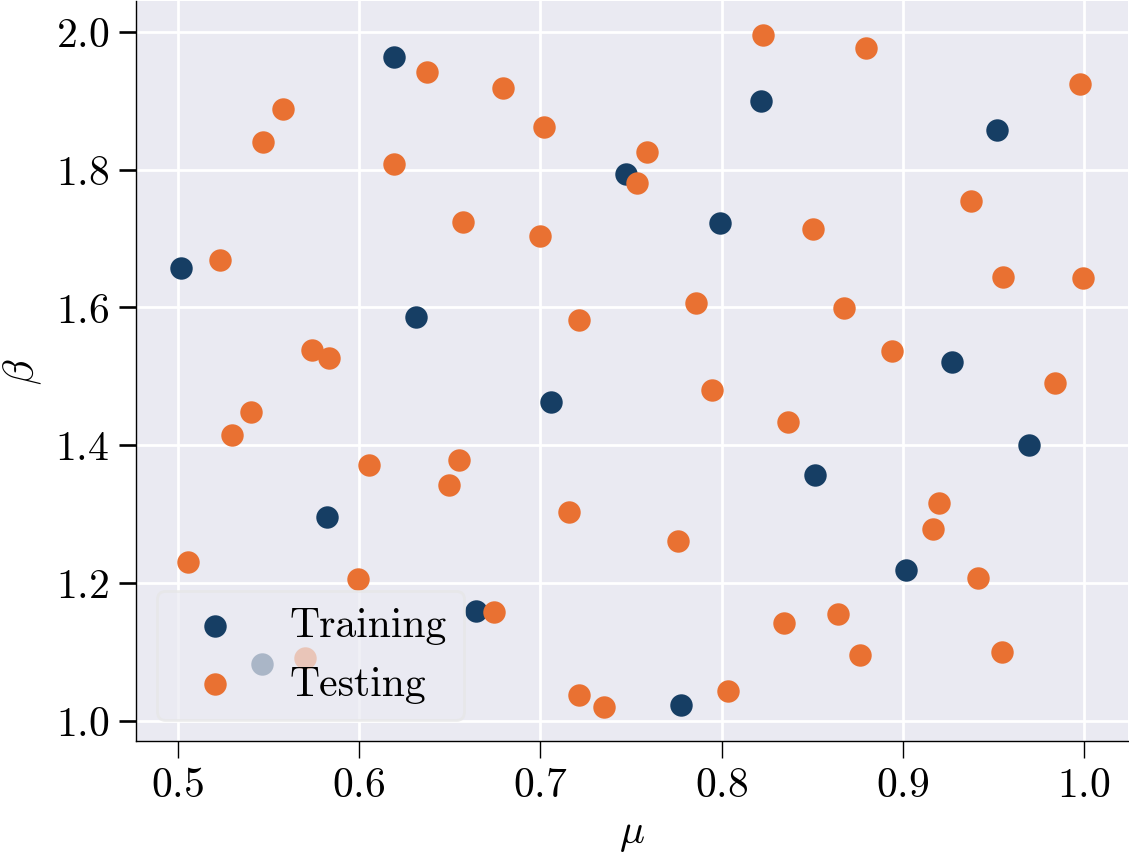

In [7]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 7


Text(0.5, 0, 'POD modes ($k$)')

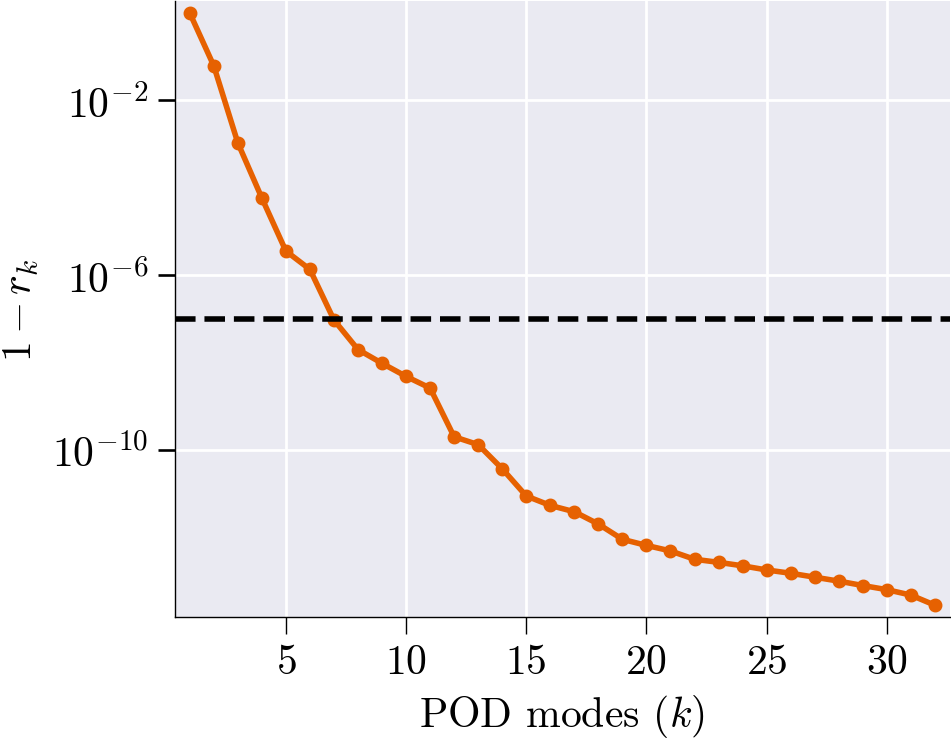

In [8]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-7,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors

n_sel = 6

# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [9]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel, train_ref=NLS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_1_h\ROM_data


In [10]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[0.99766197 1.92458373]
1 0.0008767127260733728
Snap 2/64 params=[0.54059827 1.4473822 ]
1 0.0061628753075057665
2 1.5426673586586334e-05
Snap 3/64 params=[0.7214115  1.58129626]
1 0.003809270024874058
2 5.0721724067906286e-06
Snap 4/64 params=[0.80340666 1.04287637]
1 0.009094556027483762
2 2.8321034157637766e-05
Snap 5/64 params=[0.85037287 1.71345038]
1 0.007593119080351307
2 2.5301148049186243e-05
Snap 6/64 params=[0.67456691 1.158486  ]
1 0.0028539493357613915
2 3.0330549900285766e-06
Snap 7/64 params=[0.61905883 1.80802911]
1 0.009951461241008853
2 4.2411001675720954e-05
Snap 8/64 params=[0.91981126 1.31611396]
1 0.012973501291297857
2 5.336744409990412e-05
Snap 9/64 params=[0.89425566 1.53655681]
1 0.0031342888193936582
2 4.050665117578987e-06
Snap 10/64 params=[0.57006191 1.09152122]
1 0.0019245114022704388
2 1.4820617230845618e-06
Snap 11/64 params=[0.63728873 1.94197991]
1 0.008866913302133426
2 3.2505040090809756e-05
Snap 12/64 params=[0.836536   1.43389503]

In [11]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 3.9754e-09
Relative L2 Error:        2.2812e-09
L∞ Error:                 4.3562e-09
Relative L∞ Error:        8.1744e-09
RMSE:                     3.0301e-10
MAE:                      6.0297e-11

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             0.0000e+00
95th Percentile Error:    1.3317e-10

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.0277e-11
Max Rel L2 Error over time/parameter: 3.9965e-10
Min Rel L2 Error over time/parameter: 4.9905e-13
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

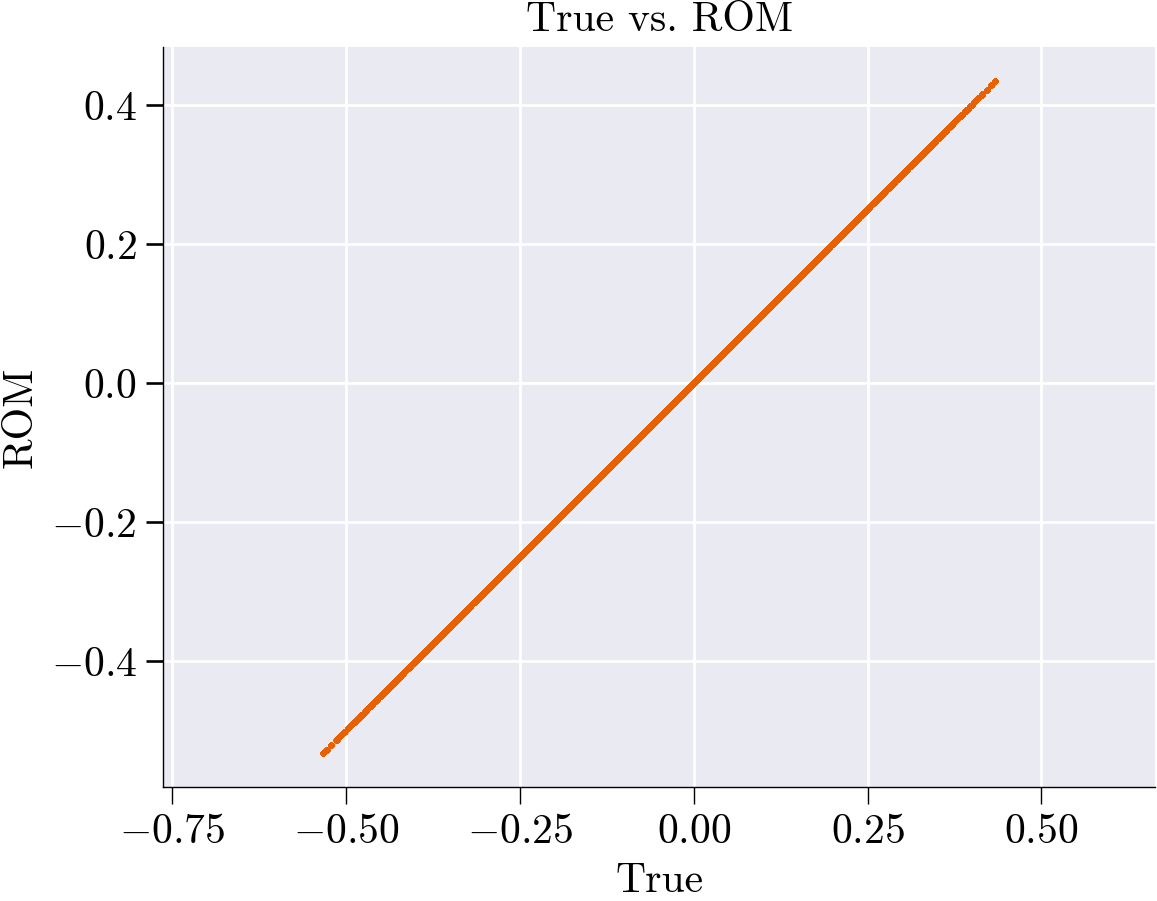

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


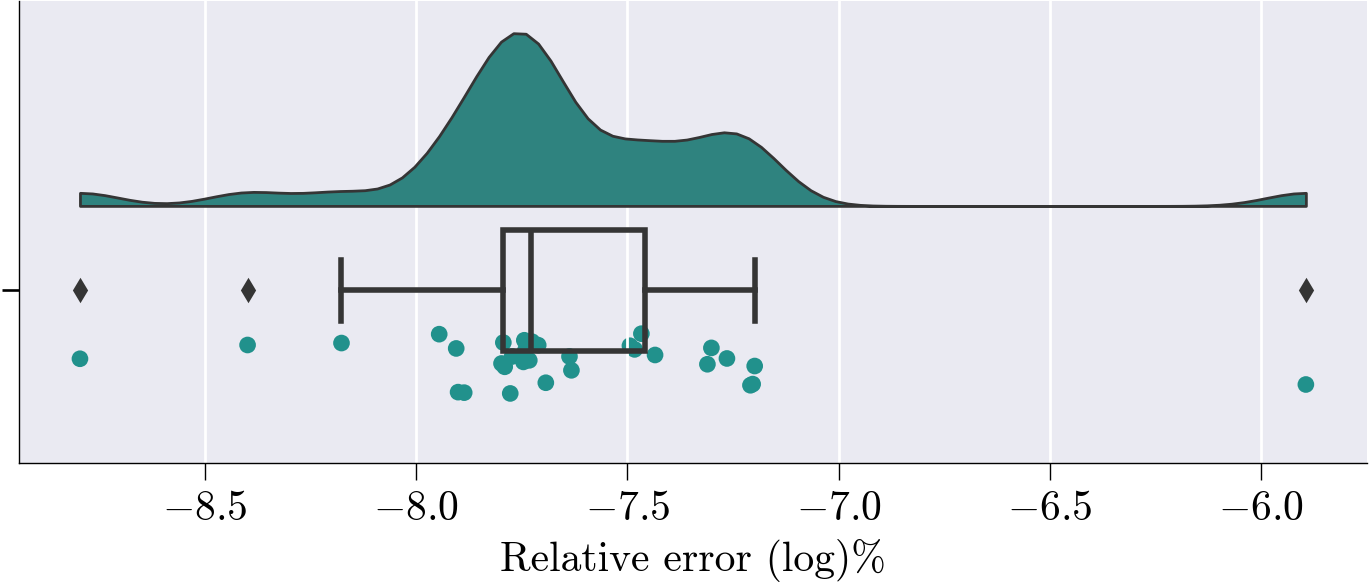

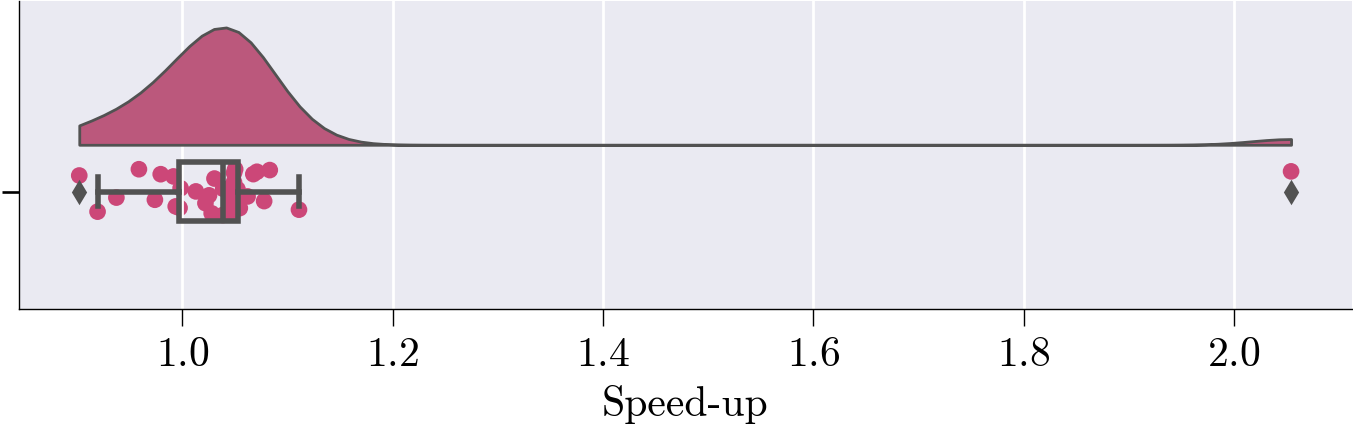

In [12]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


## Hyper ROM Simulation


### Mesh Sampling


In [13]:
prob = ProblemNonLinear()
sim_data['dirichlet_dofs'] = prob.domain()['dirichlet_dofs']
free_dofs = sim_data['basis'].item().complement_dofs(sim_data['dirichlet_dofs'])
prob.mesh = sim_data['mesh'].item()  
# Get the finite element basis object for ROM construction
# This contains the spatial discretization information and basis functions
basis = sim_data['basis'].item()


In [14]:
# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [15]:
# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
q_mus = collect_residuals(
    NLS_train_ms,         # Mean-centered training snapshots
    NLS_train_mean,       # Mean temperature field
    V_sel,                # Selected POD basis modes
    reconstruct_solution, # Solution reconstruction function
    Residual,             # ROM residual operator
    training_params,
    prob.assemble_kwargs,
)

# Display the shape of collected residuals for verification
# Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
print(q_mus.shape)

#Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(192, 1250)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 31.62704888325391


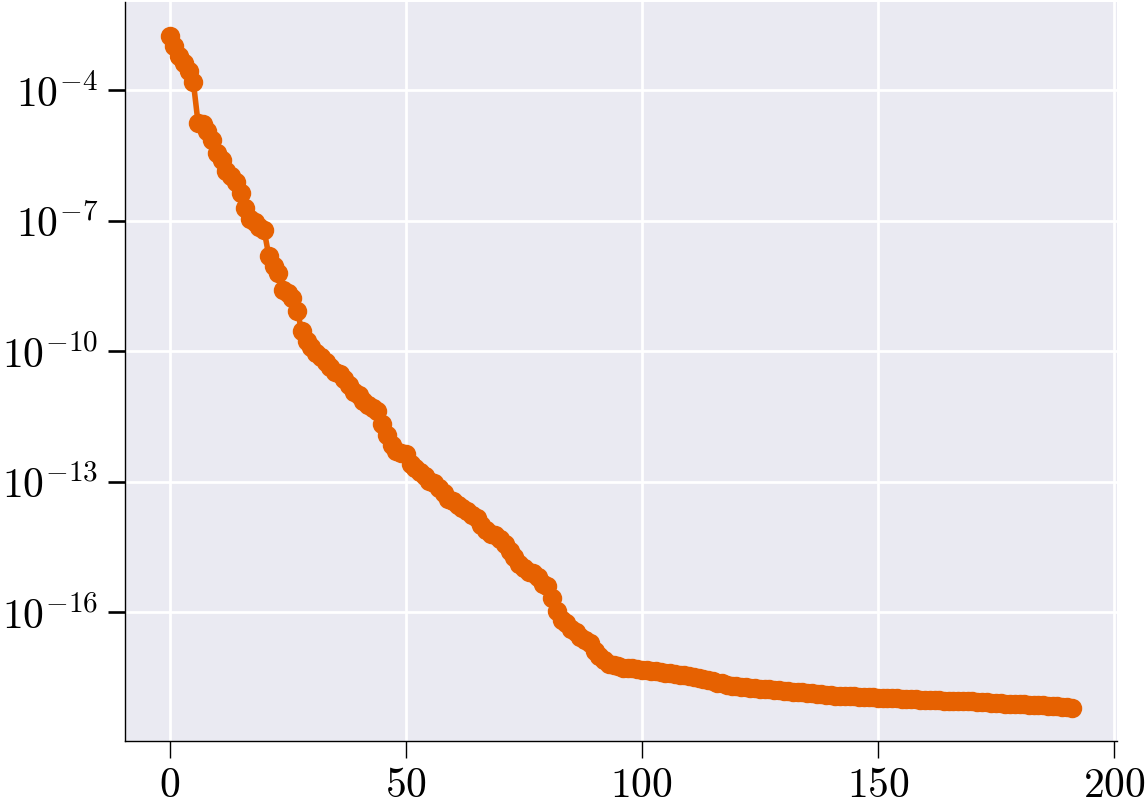

In [16]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:100]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [17]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 100 1250 0 1.100558242237526e+01 3.162704888325391e+01
1 1 100 1250 1 1.074331208920572e+01 3.150971798884815e+01
2 2 100 1250 2 1.021631689120177e+01 3.126318407987220e+01
3 3 100 1250 3 9.992135053494383e+00 3.097203407434182e+01
4 4 100 1250 4 1.002842301734087e+01 3.086335420883287e+01
5 5 100 1250 5 9.712477097322953e+00 3.041287740573789e+01
6 6 100 1250 6 9.871291395404945e+00 3.001543881315790e+01
7 7 100 1250 7 1.000042399329283e+01 2.983202861903408e+01
8 8 100 1250 8 9.114246657985184e+00 2.774760997980168e+01
9 9 100 1250 9 9.018683997331317e+00 2.754220628355395e+01
10 10 100 1250 10 8.980156922879592e+00 2.738111344865666e+01
11 11 100 1250 11 9.143442946763756e+00 2.685973290911839e+01
12 12 100 1250 12 8.541142922692964e+00 2.640715624307784e+01
13 13 100 1250 13 8.346754907460804e+00 2.627194439684820e+01
14 14 100 1250 14 6.398685012349578e+00 2.330602570993113e+01
15 15 100 1250 15 6.284729021796292e+00

#### Plot Reduced Meshes with weights

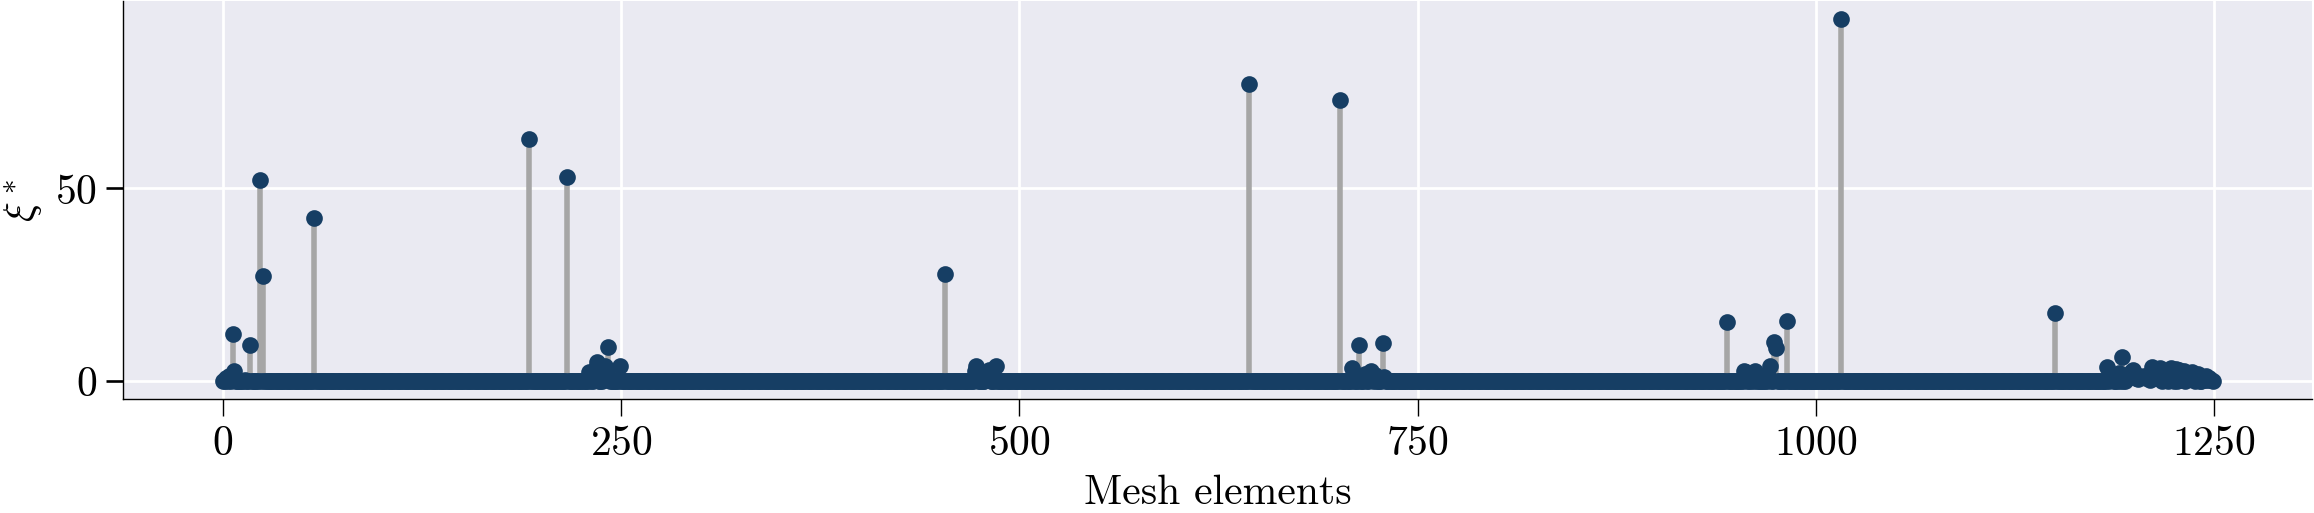

In [18]:
fig, ax = plot_ecsw_weights(x_nnls_m)

## Mesh coloring based on selected elements

hyper_basis = sim_data["basis"].item()
mesh = hyper_basis.mesh

w = np.asarray(x_nnls_m).ravel()
sel_elems = np.flatnonzero(w > 1e-8)  # element indices on the mesh

element_colors = np.zeros(mesh.nelements, dtype=float)
element_colors[sel_elems] = 1.0

mesh.save("colored_mesh.vtk", cell_data={"element_tags": [element_colors]})


### Run HyperROM simulation


In [19]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
#rom will contain the hyper_rom solution as an attribute
# rom.run_hyper_rom_simulation(np.random.rand(640));
rom.run_hyper_rom_simulation_ecsw(x_nnls_m)

Snap 1/32 params=[0.99766197 1.92458373]
1 0.1074696416884347
2 0.00012824420320857956
Snap 2/32 params=[0.54059827 1.4473822 ]
1 0.008543127199354081
2 1.8580455488392763e-05
Snap 3/32 params=[0.7214115  1.58129626]
1 0.005342751188346505
2 5.8706560653941724e-06
Snap 4/32 params=[0.80340666 1.04287637]
1 0.0120919315663819
2 3.637995393710758e-05
Snap 5/32 params=[0.85037287 1.71345038]
1 0.009990865194836364
2 3.350493912308205e-05
Snap 6/32 params=[0.67456691 1.158486  ]
1 0.003849412518107839
2 3.8159990513102415e-06
Snap 7/32 params=[0.61905883 1.80802911]
1 0.013748195955945446
2 5.167587347881403e-05
Snap 8/32 params=[0.91981126 1.31611396]
1 0.017787806697267275
2 6.415791863870355e-05
Snap 9/32 params=[0.89425566 1.53655681]
1 0.004107393225394162
2 5.383384447388106e-06
Snap 10/32 params=[0.57006191 1.09152122]
1 0.0025827008533583972
2 1.8907438615166976e-06
Snap 11/32 params=[0.63728873 1.94197991]
1 0.0123843241459254
2 3.8679151195318886e-05
Snap 12/32 params=[0.836536  

([1.0900126735449456,
  1.0167679920589172,
  1.0627953759997952,
  1.1638046985808934,
  1.0809263102979396,
  1.1133143554482419,
  0.9954784129902524,
  1.1471227217556887,
  1.113215305996924,
  1.0915514249117009,
  0.9848092248789647,
  1.1136871819792655,
  1.0418697353530826,
  1.1018612742413942,
  0.973156813817,
  1.1658050545845733,
  1.112843900055453,
  1.0393902720898949,
  1.0190060478662957,
  1.1240822954330554,
  1.0401042471514474,
  1.0715902281550578,
  1.022377849108824,
  1.1700137238075747,
  1.096162018638138,
  1.055497810093961,
  1.0216701546198093,
  1.1590072825499367,
  1.077908059368718,
  1.1524677926353057,
  0.9578816457452285,
  1.1370234699665909],
 [5.790080479037064,
  6.6757805533868,
  6.736535934693642,
  6.989432374872789,
  6.618622853261312,
  6.891286495358543,
  6.53008684244066,
  6.765225467109425,
  6.694325918544318,
  6.698750055795614,
  5.887136034329042,
  7.188092248946098,
  6.9089098223202,
  6.618618350232076,
  6.490726988336

In [20]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 1.8824e-02
Relative L2 Error:        1.0801e-02
L∞ Error:                 3.6273e-03
Relative L∞ Error:        6.8066e-03
RMSE:                     1.4348e-03
MAE:                      1.0498e-03

Statistical Fit:
R² Score:                 0.9999
Explained Variance:       0.9963

Error Distribution:
Median Error:             5.2238e-04
95th Percentile Error:    3.0932e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 3.3704e-04
Max Rel L2 Error over time/parameter: 3.6563e-04
Min Rel L2 Error over time/parameter: 2.9934e-04
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

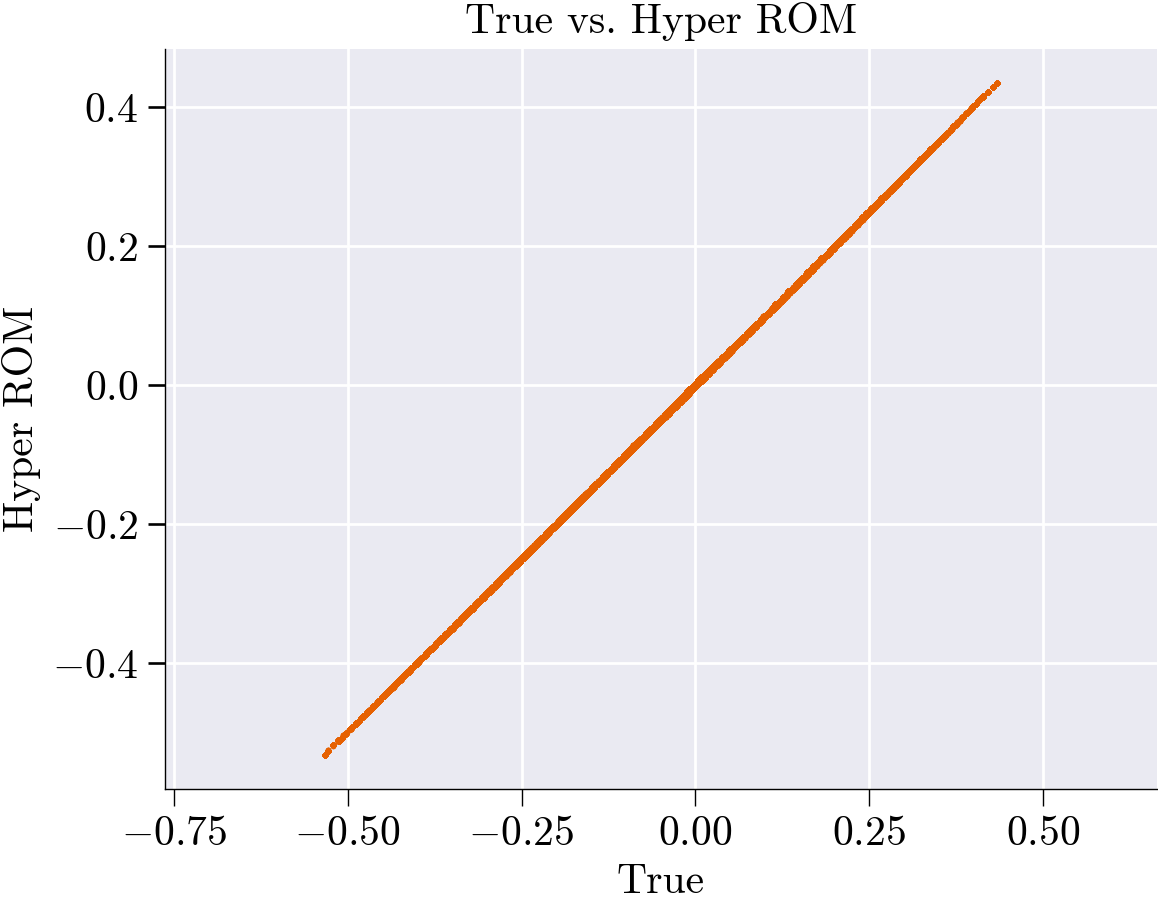

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


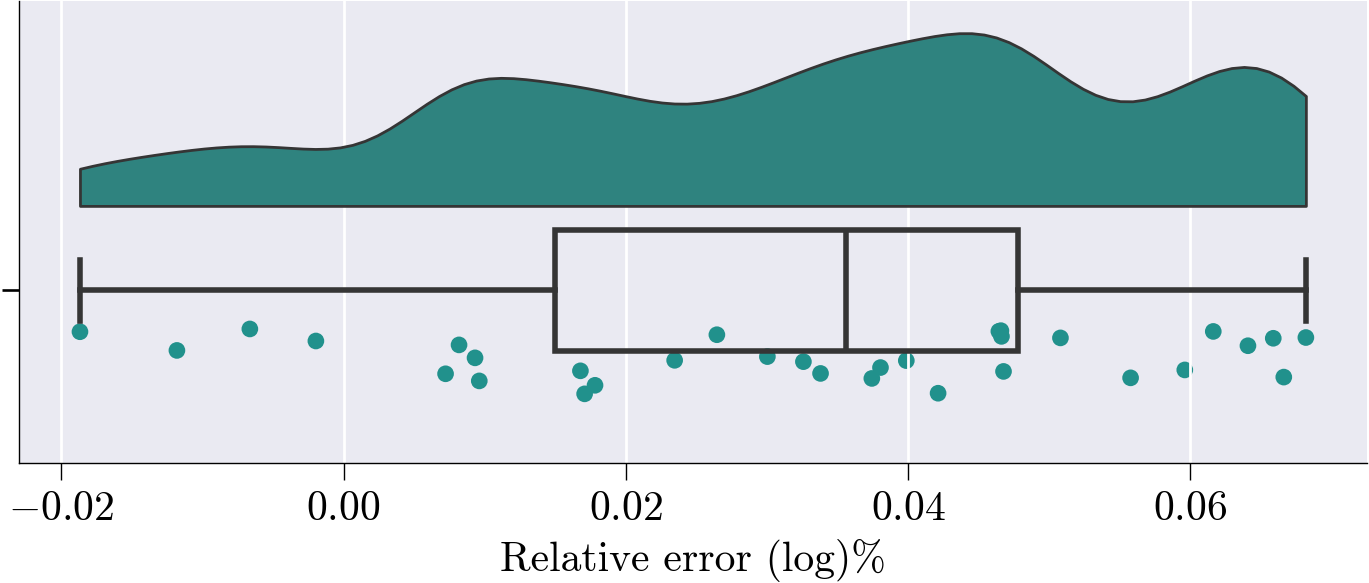

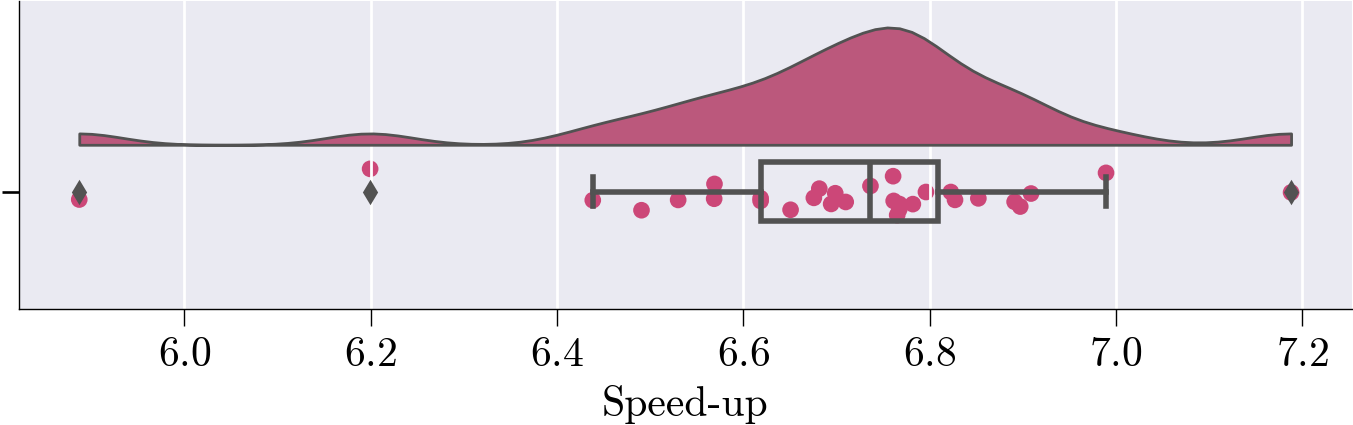

In [21]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

